In [2]:
import numpy as np
import os.path as op
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

bids_folder_numrisk = '/mnt_04/ds-numrisk' 
bids_folder_dnumrisk = '/mnt_03/ds-dnumrisk'

In [36]:
# 
probit_nr = pd.read_csv(op.join(bids_folder_numrisk, 'derivatives/phenotype','probit_model-2_all-subwise-params.csv')).set_index('subject')
probit_dnr = pd.read_csv(op.join(bids_folder_dnumrisk, 'derivatives/phenotype','probit-2_all-subwise-params_appropSample.csv')).set_index('subject')


<Axes: >

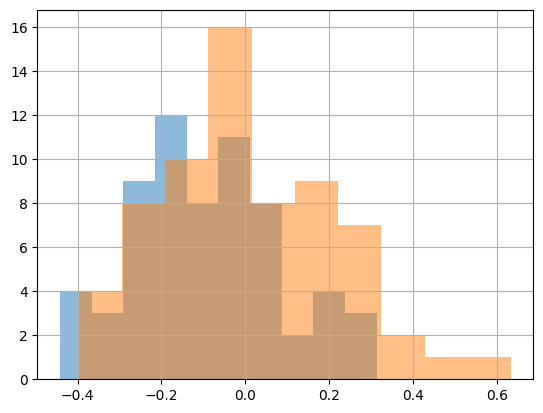

In [14]:
param = 'intercept'#'n1_slope' #'gamma'
probit_nr[param].hist(alpha=0.5)
probit_dr[param].hist(alpha=0.5)

In [18]:
from utils_02 import get_behave_bauer_params

bauer_dnr = get_behave_bauer_params(bids_folder=bids_folder_dnumrisk, dataset='dyscalc',unbiased=True)
bauer_nr = get_behave_bauer_params(bids_folder=bids_folder_numrisk, dataset='miguel',unbiased=True)

In [39]:
behav_dnr = bauer_dnr.join(probit_dnr, on='subject')
behav_nr = bauer_nr.join(probit_nr, on='subject')

df_behav = pd.concat([behav_dnr, behav_nr])

In [119]:
n_grad = 2
BND_dnr = pd.read_csv(op.join(bids_folder_dnumrisk, 'derivatives','phenotype',f'betweenNdispersion_grad-{n_grad}.csv'))
npc_dnr = pd.read_csv(op.join(bids_folder_dnumrisk, 'derivatives','phenotype', f'withinNdispersion-NPC_grad-{n_grad}.csv')).drop('group',axis=1)
neuro_dnr = BND_dnr.set_index('subject').join(npc_dnr.set_index('subject'))
neuro_dnr['dataset'] = 'dyscalc'
neuro_dnr.set_index(['dataset'], append=True,inplace=True)


BND_nr = pd.read_csv(op.join(bids_folder_numrisk, 'derivatives','phenotype',f'betweenNdispersion_grad-{n_grad}.csv'))
npc_nr = pd.read_csv(op.join(bids_folder_numrisk, 'derivatives','phenotype', f'withinNdispersion-NPC_grad-{n_grad}.csv'))
neuro_nr = BND_nr.set_index('subject').join(npc_nr.set_index('subject'))
neuro_nr['dataset'] = 'miguel'
neuro_nr.set_index(['dataset'], append=True,inplace=True)

In [128]:
n_grad = 1
neuro_dnr = pd.read_csv(op.join(bids_folder_dnumrisk, 'derivatives','phenotype',f'betweenNdispersion_grad-{n_grad}.csv'))
neuro_dnr['dataset'] = 'dyscalc'
neuro_dnr.set_index(['subject','dataset'], inplace=True)

neuro_nr = pd.read_csv(op.join(bids_folder_numrisk, 'derivatives','phenotype',f'betweenNdispersion_grad-{n_grad}.csv'))
neuro_nr['dataset'] = 'miguel'
neuro_nr.set_index(['subject','dataset'], inplace=True)

In [129]:
df_neuro= pd.concat([neuro_nr, neuro_dnr])#drop(columns='group', inplace=True)
df_neuro.loc[pd.isna(df_neuro['group']), 'group'] = 0 #'control_miguel'
df_neuro.loc[df_neuro['group'] == 0, 'group'] = 0 #'control_dyscalc'
df_neuro.loc[df_neuro['group'] == 1, 'group'] = 1 #'dyscalc'

In [130]:
df_comb = df_neuro.join(df_behav.drop('group',axis=1))
df_comb.reset_index(inplace=True)
df_comb['dataset'] = np.where(df_comb['dataset']=='dyscalc',1,0)
df_comb = df_comb.set_index(['subject','dataset'])
df_comb.head()

,,Visual1 - Visual1,Visual1 - Visual2,Visual1 - Somatomotor,Visual1 - Cingulo-Opercular,Visual1 - Dorsal-attention,Visual1 - Language,Visual1 - Frontoparietal,Visual1 - Auditory,Visual1 - Default,Visual1 - Posterior-Multimodal,...,Posterior-Multimodal - Orbito-Affective,Ventral-Multimodal - Ventral-Multimodal,Ventral-Multimodal - Orbito-Affective,Orbito-Affective - Orbito-Affective,group,memory_noise_sd,perceptual_noise_sd,gamma,intercept,n1_slope
subject,dataset,,,,,,,,,,,,,,,,,,,,,
40,0,0.0,0.664022,7.671795,4.036688,3.353490,1.901826,1.395971,2.868778,0.454497,1.079192,...,1.272443,0.0,1.325639,0.0,0.0,0.172125,0.150022,3.066083,-0.303475,0.020325
62,0,0.0,0.369677,7.246345,3.530148,4.034488,0.796750,1.508222,3.670520,2.090956,1.832790,...,2.238615,0.0,0.428569,0.0,0.0,0.163272,0.190866,2.780192,-0.397752,0.014520
41,0,0.0,0.859463,6.186279,2.602706,2.524632,1.125188,0.558282,2.632790,1.566569,2.322125,...,3.255200,0.0,0.653705,0.0,0.0,0.204029,0.127207,3.279987,0.073945,0.042370
31,0,0.0,0.522492,6.268041,3.164147,2.140653,0.987398,0.270469,4.362975,3.015885,2.603414,...,5.006970,0.0,0.931461,0.0,0.0,0.141577,0.114351,3.921074,0.001643,0.032300
64,0,0.0,0.522217,9.291824,5.114043,3.846031,2.903377,0.584300,5.620427,1.011894,3.034221,...,1.431972,0.0,1.287165,0.0,0.0,0.203329,0.149707,2.932112,0.047845,0.036839


In [122]:
# for grad - 2
net_name = 'Visual2 - Dorsal-attention'
behav_vars = ['memory_noise_sd','perceptual_noise_sd','gamma','n1_slope']
neural_vars = ['NPC_dispersion', net_name]

In [134]:
net_name = 'Visual1 - Cingulo-Opercular'
behav_vars = ['memory_noise_sd','perceptual_noise_sd','gamma','n1_slope']
neural_vars = [net_name]

In [138]:
import statsmodels.api as sm

ind_var = 'behaveVar' 
dep_var =   'neuralVar'
formula = f'{dep_var} ~ {ind_var} + group + dataset'

param_list = ['Intercept', ind_var, 'group', 'dataset']
index = pd.MultiIndex.from_product([neural_vars, behav_vars, param_list], 
                                   names=['NeuralVar', 'BehavVar', 'param'])
model_fits_df = pd.DataFrame(index=index, columns=['p_val', 'coef'])

# Populate the DataFrame
for y_var in neural_vars:
    for x_var in behav_vars:
        df_comb['neuralVar'] = np.log(df_comb[y_var])
        df_comb['behaveVar'] = np.log(df_comb[x_var])
        result = sm.formula.ols(formula=formula, data=df_comb.reset_index()).fit()

        for param in param_list: # 
            model_fits_df.loc[(y_var, x_var, param), 'p_val'] = result.pvalues.get(param, np.nan)
            model_fits_df.loc[(y_var, x_var, param), 'coef'] = result.params.get(param, np.nan)


In [136]:
# onnly one dataset
import statsmodels.api as sm

tmp = df_comb.xs(0, level='dataset')

ind_var = 'behaveVar' 
dep_var =   'neuralVar'
formula = f'{dep_var} ~ {ind_var}'

param_list = ['Intercept', ind_var, 'group', 'dataset']
index = pd.MultiIndex.from_product([neural_vars, behav_vars, param_list], 
                                   names=['NeuralVar', 'BehavVar', 'param'])
model_fits_df = pd.DataFrame(index=index, columns=['p_val', 'coef'])

# Populate the DataFrame
for y_var in neural_vars:
    for x_var in behav_vars:
        tmp['neuralVar'] = np.log(tmp[y_var])
        tmp['behaveVar'] = np.log(tmp[x_var])
        result = sm.formula.ols(formula=formula, data=tmp).fit()

        for param in param_list: # 
            model_fits_df.loc[(y_var, x_var, param), 'p_val'] = result.pvalues.get(param, np.nan)
            model_fits_df.loc[(y_var, x_var, param), 'coef'] = result.params.get(param, np.nan)


/tmp/ipykernel_972133/4279492468.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp['neuralVar'] = np.log(tmp[y_var])
/tmp/ipykernel_972133/4279492468.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp['behaveVar'] = np.log(tmp[x_var])
/tmp/ipykernel_972133/4279492468.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs

In [137]:
print(formula)
print(f'gradient-{n_grad}')

model_fits_df

neuralVar ~ behaveVar
gradient-1


p_val      coef
NeuralVar                   BehavVar            param                        
Visual1 - Cingulo-Opercular memory_noise_sd     Intercept  0.000002  1.386051
                                                behaveVar  0.806775 -0.037354
                                                group           NaN       NaN
                                                dataset         NaN       NaN
                            perceptual_noise_sd Intercept  0.000197  1.310829
                                                behaveVar   0.67212 -0.071649
                                                group           NaN       NaN
                                                dataset         NaN       NaN
                            gamma               Intercept       0.0  1.360208
                                                behaveVar  0.647584  0.078855
                                                group           NaN       NaN
                                                dataset         NaN       NaN
                            n1_slope            Intercept  0.000192  1.599237
                                                behaveVar  0.712304  0.041994
                                                group           NaN       NaN
                                                dataset         NaN       NaN

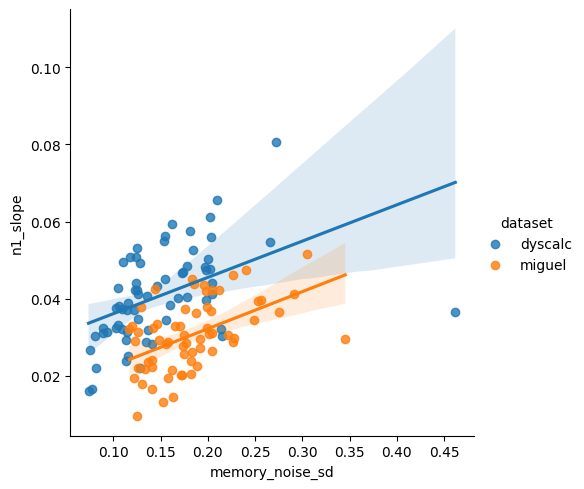

In [99]:
sns.lmplot(x='memory_noise_sd', y='n1_slope', data=df_behav.reset_index(), hue='dataset') #, hue='group'